In [1]:
import pandas as pd 
import numpy as np 
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,root_mean_squared_error

df = pd.read_csv("../data/household_power_consumption.txt",sep=";",low_memory=False,na_values="?")
df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [2]:
    # 3️⃣ Build input array
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn
import scipy

print("Python      :", sys.version)
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Scikit-Learn:", sklearn.__version__)
print("Matplotlib  :", matplotlib.__version__)
print("Seaborn     :", seaborn.__version__)
print("SciPy       :", scipy.__version__)

Python      : 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
NumPy       : 2.1.3
Pandas      : 2.3.1
Scikit-Learn: 1.7.2
Matplotlib  : 3.10.0
Seaborn     : 0.13.2
SciPy       : 1.15.3


In [11]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df.set_index("Datetime", inplace=True)
df.sort_index(inplace=True)

In [12]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [13]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [14]:
df.shape

(2075259, 9)

In [15]:
df["Energy_kWh"] = df["Global_active_power"] / 60

In [16]:

# Monthly Energy Consumption
monthly_energy = df["Energy_kWh"].resample("ME").sum()

# Convert Series -> DataFrame
monthly_df = monthly_energy.to_frame(name="Energy_kWh")

In [46]:
# Lag Features
monthly_df["lag_1"] = monthly_df["Energy_kWh"].shift(1)
monthly_df["lag_2"] = monthly_df["Energy_kWh"].shift(2)
monthly_df["lag_3"] = monthly_df["Energy_kWh"].shift(3)
monthly_df["lag_12"] = monthly_df["Energy_kWh"].shift(12)

# Rolling Mean (previous 3 months only)
monthly_df["rolling_mean_3"] = (
    monthly_df["Energy_kWh"]
    .shift(1)
    .rolling(window=3)
    .mean()
)
monthly_df["trend"] = range(len(monthly_df))

In [47]:
monthly_df.dropna(inplace=True)

In [48]:
monthly_df.shape

(12, 7)

In [27]:
monthly_df["Energy_kWh"].mean()

np.float64(780.1423907407407)

In [49]:
X = monthly_df[
    [
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_12",
        "rolling_mean_3"
    ]
]

y = monthly_df["Energy_kWh"]

In [44]:

train_size = int(len(monthly_df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [45]:
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error
)

results = {}

for alpha in [0.01, 0.1, 1, 10, 100]:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results[alpha] = {
        "model": model,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

# Print all results
print("Alpha\tMAE\t\tRMSE\t\tMAPE")
print("-" * 55)

for alpha, metrics in results.items():
    print(
        f"{alpha:<6}\t"
        f"{metrics['MAE']:.2f}\t"
        f"{metrics['RMSE']:.2f}\t"
        f"{metrics['MAPE']:.2f}%"
    )

# Best model (based on RMSE)
best_alpha = min(results, key=lambda a: results[a]["RMSE"])
best_model = results[best_alpha]["model"]

print("\nBest Ridge Model")
print(f"Alpha : {best_alpha}")
print(f"MAE   : {results[best_alpha]['MAE']:.2f}")
print(f"RMSE  : {results[best_alpha]['RMSE']:.2f}")
print(f"MAPE  : {results[best_alpha]['MAPE']:.2f}%")

Alpha	MAE		RMSE		MAPE
-------------------------------------------------------
0.01  	137.86	151.82	24.61%
0.1   	137.86	151.82	24.61%
1     	137.86	151.82	24.61%
10    	137.86	151.82	24.60%
100   	137.82	151.79	24.60%

Best Ridge Model
Alpha : 100
MAE   : 137.82
RMSE  : 151.79
MAPE  : 24.60%


In [50]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# ==========================
# Load Dataset
# ==========================

df = pd.read_csv(
    "../data/household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values="?"
)

# ==========================
# Datetime Handling
# ==========================

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df.set_index("Datetime", inplace=True)
df.sort_index(inplace=True)

df.drop(columns=["Date", "Time"], inplace=True)

# ==========================
# Convert Numeric
# ==========================

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================
# Convert to Energy (kWh)
# ==========================

df["Energy_kWh"] = df["Global_active_power"] / 60

# ==========================
# Monthly Aggregation
# ==========================

monthly_energy = df["Energy_kWh"].resample("M").sum()
monthly_df = monthly_energy.to_frame(name="Energy_kWh")

# ==========================
# Feature Engineering
# ==========================

monthly_df["lag_1"] = monthly_df["Energy_kWh"].shift(1)
monthly_df["lag_2"] = monthly_df["Energy_kWh"].shift(2)
monthly_df["lag_3"] = monthly_df["Energy_kWh"].shift(3)
monthly_df["lag_12"] = monthly_df["Energy_kWh"].shift(12)

monthly_df["rolling_mean_3"] = (
    monthly_df["Energy_kWh"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

monthly_df.dropna(inplace=True)

print("Final dataset shape:", monthly_df.shape)
print("Mean monthly energy:", monthly_df["Energy_kWh"].mean())

# ==========================
# Features & Target
# ==========================

X = monthly_df[
    ["lag_1", "lag_2", "lag_3", "lag_12", "rolling_mean_3"]
]

y = monthly_df["Energy_kWh"]

# ==========================
# Train/Test Split
# ==========================

train_size = int(len(monthly_df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# ==========================
# Ridge Hyperparameter Tuning
# ==========================

results = {}

for alpha in [0.01, 0.1, 1, 10, 100]:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results[alpha] = {
        "model": model,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

print("\nAlpha\tMAE\t\tRMSE\t\tMAPE")
print("-" * 55)

for alpha, metrics in results.items():
    print(
        f"{alpha:<6}\t"
        f"{metrics['MAE']:.2f}\t"
        f"{metrics['RMSE']:.2f}\t"
        f"{metrics['MAPE']:.2f}%"
    )

best_alpha = min(results, key=lambda a: results[a]["RMSE"])
best_model = results[best_alpha]["model"]

print("\nBest Ridge Model")
print(f"Alpha : {best_alpha}")
print(f"MAE   : {results[best_alpha]['MAE']:.2f}")
print(f"RMSE  : {results[best_alpha]['RMSE']:.2f}")
print(f"MAPE  : {results[best_alpha]['MAPE']:.2f}%")

Final dataset shape: (36, 6)
Mean monthly energy: 780.1423907407407

Alpha	MAE		RMSE		MAPE
-------------------------------------------------------
0.01  	82.86	110.82	14.62%
0.1   	82.86	110.82	14.62%
1     	82.86	110.82	14.62%
10    	82.86	110.82	14.62%
100   	82.87	110.82	14.62%

Best Ridge Model
Alpha : 0.01
MAE   : 82.86
RMSE  : 110.82
MAPE  : 14.62%


In [58]:
df_exp = monthly_energy.to_frame(name="Energy_kWh")

df_exp["lag_1"] = df_exp["Energy_kWh"].shift(1)
df_exp["lag_2"] = df_exp["Energy_kWh"].shift(2)
df_exp["lag_3"] = df_exp["Energy_kWh"].shift(3)
df_exp["lag_12"] = df_exp["Energy_kWh"].shift(12)

df_exp = df_exp.dropna()

df_exp["trend"] = range(len(df_exp))


X = df_exp[["lag_1", "lag_2", "lag_3", "lag_12", "trend"]]
y = df_exp["Energy_kWh"]

In [59]:
train_size = int(len(monthly_df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# ==========================
# Ridge Hyperparameter Tuning
# ==========================

results = {}

for alpha in [0.01, 0.1, 1, 10, 100]:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results[alpha] = {
        "model": model,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

print("\nAlpha\tMAE\t\tRMSE\t\tMAPE")
print("-" * 55)

for alpha, metrics in results.items():
    print(
        f"{alpha:<6}\t"
        f"{metrics['MAE']:.2f}\t"
        f"{metrics['RMSE']:.2f}\t"
        f"{metrics['MAPE']:.2f}%"
    )

best_alpha = min(results, key=lambda a: results[a]["RMSE"])
best_model = results[best_alpha]["model"]

print("\nBest Ridge Model")
print(f"Alpha : {best_alpha}")
print(f"MAE   : {results[best_alpha]['MAE']:.2f}")
print(f"RMSE  : {results[best_alpha]['RMSE']:.2f}")
print(f"MAPE  : {results[best_alpha]['MAPE']:.2f}%")


Alpha	MAE		RMSE		MAPE
-------------------------------------------------------
0.01  	78.63	96.37	12.91%
0.1   	78.63	96.37	12.91%
1     	78.63	96.37	12.91%
10    	78.59	96.40	12.91%
100   	78.20	96.69	12.91%

Best Ridge Model
Alpha : 0.01
MAE   : 78.63
RMSE  : 96.37
MAPE  : 12.91%


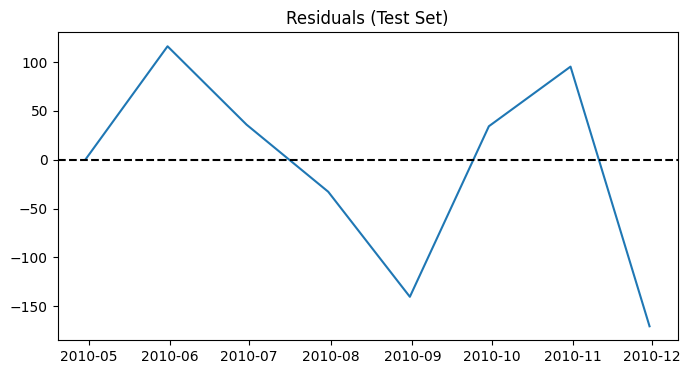

In [62]:
import matplotlib.pyplot as plt
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
plt.plot(residuals)
plt.title("Residuals (Test Set)")
plt.axhline(0, color="black", linestyle="--")
plt.show()

maharashtra tariff calculator

In [63]:
MAHARASHTRA_TARIFF = [
    (100, 3.50),
    (200, 7.00),
    (200, 9.00),
    (float("inf"), 11.00)
]

In [64]:
def calculate_maharashtra_bill(units, slabs=MAHARASHTRA_TARIFF):
    remaining_units = units
    total_bill = 0

    for slab_units, rate in slabs:
        if remaining_units <= 0:
            break

        units_in_slab = min(remaining_units, slab_units)
        total_bill += units_in_slab * rate
        remaining_units -= units_in_slab

    return round(total_bill, 2)

In [67]:
print(calculate_maharashtra_bill(150))
print(calculate_maharashtra_bill(350))
print(calculate_maharashtra_bill(1000))
print(calculate_maharashtra_bill(0))
print(calculate_maharashtra_bill(50))

700.0
2200.0
9050.0
0
175.0


In [69]:
INDIA_EMISSION_FACTOR = 0.82  # kg CO2 per kWh

def calculate_carbon_footprint(units, emission_factor=INDIA_EMISSION_FACTOR):
    return round(units * emission_factor, 2)

In [70]:
def calculate_tree_equivalent(carbon_kg):
    monthly_absorption_per_tree = 21 / 12  # ~1.75 kg
    return round(carbon_kg / monthly_absorption_per_tree, 2)

In [71]:
def calculate_vehicle_equivalent(carbon_kg):
    emission_per_km = 0.192
    return round(carbon_kg / emission_per_km, 2)

In [72]:
def carbon_intelligence(units):
    carbon = calculate_carbon_footprint(units)
    trees = calculate_tree_equivalent(carbon)
    vehicle_km = calculate_vehicle_equivalent(carbon)

    return {
        "carbon_kg": carbon,
        "trees_required": trees,
        "vehicle_km_equivalent": vehicle_km
    }

In [73]:
carbon_data = carbon_intelligence(780)
print(carbon_data)

{'carbon_kg': 639.6, 'trees_required': 365.49, 'vehicle_km_equivalent': 3331.25}


In [74]:
import joblib
joblib.dump(best_model,"../models/ridge_model.pkl")

['../models/ridge_model.pkl']

In [75]:
feature_columns = ["lag_1", "lag_2", "lag_3", "lag_12", "trend"]

with open("../models/features.txt", "w") as f:
    for col in feature_columns:
        f.write(col + "\n")

In [76]:
import json

metadata = {
    "model_type": "Ridge",
    "alpha": 0.01,
    "mae": float(mae),
    "rmse": float(rmse),
    "mape": float(mape),
    "mean_monthly_energy": float(monthly_df["Energy_kWh"].mean())
}

with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [77]:
last_12 = monthly_df["Energy_kWh"].tail(12).tolist()

with open("../models/last_12_values.json", "w") as f:
    json.dump(last_12, f, indent=4)

In [78]:
seasonal_pattern = (
    monthly_df
    .groupby(monthly_df.index.month)["Energy_kWh"]
    .mean()
)

print(seasonal_pattern)

Datetime
1     1041.661378
2      861.249267
3      880.585989
4      788.131333
5      776.800500
6      657.618756
7      529.197856
8      352.898100
9      675.587667
10     853.989633
11     886.526611
12    1057.461600
Name: Energy_kWh, dtype: float64


In [79]:
high_season_months = seasonal_pattern.nlargest(3).index.tolist()
low_season_months = seasonal_pattern.nsmallest(3).index.tolist()

In [80]:
monthly_df["year"] = monthly_df.index.year

yearly_avg = monthly_df.groupby("year")["Energy_kWh"].mean()

print(yearly_avg)

year
2007    1210.069500
2008     784.573742
2009     780.993331
2010     735.295609
Name: Energy_kWh, dtype: float64


In [81]:
high_season_months

[12, 1, 11]

In [82]:
low_season_months

[8, 7, 6]

In [ ]:
def generate_ai_insights(predicted_units, last_month_units, month,
                         high_season_months, low_season_months):

    insights = []

    # 1️⃣ Seasonal Insight
    if month in high_season_months:
        insights.append("This month historically sees higher electricity usage.")
    elif month in low_season_months:
        insights.append("This month typically has lower electricity demand.")

    # 2️⃣ Month-over-Month Comparison
    change_pct = ((predicted_units - last_month_units) / last_month_units) * 100

    if change_pct > 10:
        insights.append("Projected usage is significantly higher than last month.")
    elif change_pct < -10:
        insights.append("Projected usage is significantly lower than last month.")

    # 3️⃣ Tariff Warning
    if predicted_units > 500:
        insights.append("You are entering the highest electricity tariff slab.")

    # 4️⃣ Carbon Warning
    carbon = predicted_units * 0.82
    if carbon > 600:
        insights.append("Your carbon footprint is relatively high this month.")

    return insights